In [1]:
import pandas as pd;
import seaborn as sns;
import numpy as np;
import matplotlib.pyplot as plt;

In [2]:
df = pd.read_csv(r"C:\Users\shant\python_fctp\Project\retail_sales_50k_messy.csv")

In [3]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

## Data Cleaning

In [4]:
# Changing data types

df = df.convert_dtypes()

In [5]:
# Changing date formate

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [6]:
# Invalid Dates

print("Invalid dates:", df['order_date'].isnull().sum())

Invalid dates: 37425


In [7]:
df.dtypes

order_id                     Int64
order_date          datetime64[ns]
city                string[python]
region              string[python]
category            string[python]
product             string[python]
quantity                     Int64
unit_price                 Float64
discount_percent             Int64
final_unit_price           Float64
revenue                    Float64
payment_method      string[python]
customer_type       string[python]
sales_channel       string[python]
dtype: object

In [8]:
df['city'].value_counts()

city
delhi        4645
MUMBAI       4636
Pune         4582
Chennai      4582
Bengaluru    4556
Delhi        4541
Bangalore    4526
Hyderabad    4483
Kolkata      4478
Mumbai       4472
Name: count, dtype: Int64

In [9]:
# Convert to lower case and strip the white spaces

df['city'] = df['city'].str.lower().str.strip()

In [10]:
# Replacing the city name 

df['city'] = df['city'].replace({
    'bangalore': 'bengaluru'
})

In [11]:
print(df['city'].unique())

<StringArray>
['bengaluru', 'kolkata', 'mumbai', 'delhi', <NA>, 'chennai', 'pune',
 'hyderabad']
Length: 8, dtype: string


In [12]:
# missing revenue
missing_revenue = df['revenue'].isna().sum()
print('missing_revenue:', missing_revenue)

missing_revenue: 15258


In [13]:
df = df[df['quantity']>0]

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(33386, 14)

In [16]:
Q1 = df['unit_price'].quantile(0.25)

Q3 = df['unit_price'].quantile(0.75)

IQR = Q3 - Q1

df = df[(df['unit_price'] >= Q1 - 1.5*IQR) &
    (df['unit_price'] <= Q3 + 1.5*IQR)]


In [17]:
df['discount_percent'] = df['discount_percent'].fillna(0)

df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount_percent']/100)

In [18]:
df['revenue'].head(10)

0       11521.49
1      37455.726
3       13340.77
4     10796.2275
5     25158.5555
7       10450.89
8       57258.38
9      38975.724
11      2303.968
12      190065.8
Name: revenue, dtype: Float64

In [19]:
print("Valid Transactions:", len(df))

Valid Transactions: 32706


## Solving Questions

In [20]:
 # 1. How many rows and columns are present in the dataset?

print("Rows  Columns")
print(df.shape)


Rows  Columns
(32706, 14)


In [21]:
 # 2. What percentage of missing values exists in each column?

(df.isnull().mean()*100).round(2)

order_id             0.00
order_date          74.99
city                 9.03
region              36.64
category             0.00
product              0.00
quantity             0.00
unit_price           0.00
discount_percent     0.00
final_unit_price    16.96
revenue              0.00
payment_method      19.74
customer_type       33.22
sales_channel        0.00
dtype: float64

In [22]:
# 3. Which columns have the highest data quality issues?

high_missing_data = (df.isna().mean() * 100).idxmax()
print("high_missing_data: ",high_missing_data)

high_missing_data:  order_date


In [23]:
# 4. How many duplicate order IDs are present?

duplicate_order_id = df['order_id'][df['order_id'].duplicated()].count()
print('duplicate_order_id : ', duplicate_order_id)

duplicate_order_id :  64


In [24]:
 # 5. How many invalid or negative quantities exist?


invalid_quantity = (df['quantity'] <= 0).sum()
print(invalid_quantity)

0


In [25]:
# 6. How many records have missing or incorrect dates?

missing_dates = df['order_date'].isna().sum()
print('missing_dates:', missing_dates)

missing_dates: 24527


In [26]:
# parsed_dates = pd.to_datetime(df['order_date'], errors='coerce')
# print(parsed_dates)
# invalid_dates = parsed_dates.isna().sum() - missing_dates
# print('invalid_dates: ', invalid_dates)

In [27]:
# 7.  List all inconsistent city name variations.

df['city'].value_counts()


city
delhi        6046
mumbai       5958
bengaluru    5899
chennai      3024
pune         2998
kolkata      2936
hyderabad    2893
Name: count, dtype: Int64

In [28]:
# 8. Which rows contain extreme price outliers?

df.loc[df['unit_price'].idxmax()]

order_id                      132511
order_date                       NaT
city                       bengaluru
region                         South
category                     Fashion
product                      T-Shirt
quantity                           3
unit_price                  49999.51
discount_percent                   0
final_unit_price            49999.51
revenue                    149998.53
payment_method      Cash on Delivery
customer_type                   <NA>
sales_channel               In-Store
Name: 32511, dtype: object

In [29]:
# 9. How many rows have missing revenue values?

missing_revenue = df['revenue'].isna().sum()
missing_revenue

np.int64(0)

In [30]:
# 10. After cleaning, how many valid transactions remain?

df.shape


(32706, 14)

In [31]:
df.columns

Index(['order_id', 'order_date', 'city', 'region', 'category', 'product',
       'quantity', 'unit_price', 'discount_percent', 'final_unit_price',
       'revenue', 'payment_method', 'customer_type', 'sales_channel'],
      dtype='object')

## Descriptive EDA

In [32]:
# 1. What is the total revenue generated?


total_revenue = df['revenue'].sum()
print('Total Revenue: ', total_revenue)

Total Revenue:  1877819549.0425


In [33]:
# 2.  What is the average order value?


avg_order_value = df.groupby('order_id')['revenue'].sum().mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 57527.7112015961


In [34]:
# 3. Which city generates the highest revenue?

high_city_revenue = df.groupby('city')['revenue'].sum().sort_values(ascending = False).head(1)
print("highest revenue", high_city_revenue)


highest revenue city
delhi    345946364.7035
Name: revenue, dtype: Float64


In [35]:
# 4. Which region performs best overall?

best_performance_region = df.groupby('region')['revenue'].sum().sort_values(ascending = False).head(1)

print('best_performance_region:',best_performance_region)

best_performance_region: region
South    505120474.394
Name: revenue, dtype: Float64


In [36]:
# 5. What are the top 10 selling products by revenue?

top_10_product = df.groupby('product')['revenue'].sum().sort_values(ascending = False).head(10)
print('top_10_product: ', top_10_product)

top_10_product:  product
Sneakers           122821188.438
Mixer Grinder     121746428.9865
Jeans              120004122.907
T-Shirt           119516549.2035
Smartwatch         119218768.469
Water Purifier    118073223.4725
Perfume            117412058.263
Headphones         117180613.042
Cookware Set       117026826.741
Moisturizer        116338393.896
Name: revenue, dtype: Float64


In [37]:
# 6. Which product category contributes most to revenue?

top_category = df.groupby('category')['revenue'].sum().sort_values(ascending = False).head(1)
print('Top Catagory: ', top_category)

Top Catagory:  category
Fashion    477511257.3825
Name: revenue, dtype: Float64


In [38]:
# 7. What is the least performing category?

least_category = df.groupby('category')['revenue'].sum().sort_values(ascending = False).tail(1)
print('Least Catagory: ', least_category)

Least Catagory:  category
Beauty    462412706.7995
Name: revenue, dtype: Float64


In [39]:
# 8. What is the median quantity per order?

avg_quantity_per_order = df.groupby('order_id')['quantity'].sum().mean()
print('Median Quantity Per Order:', avg_quantity_per_order)

Median Quantity Per Order: 2.5046872127933337


In [40]:
# 9. Which payment method is used most frequently?

# df['payment_method'].value_counts()
freq_used_pay_method = df['payment_method'].value_counts()
# print(freq_used_pay_method)
print('most frequently Used Payment Method: ', freq_used_pay_method.idxmax())

most frequently Used Payment Method:  Credit Card


In [41]:
# 10. What percentage of sales comes from online vs in-store?

total_revenue = df['revenue'].sum()
# print('Total Revenue:',total_revenue)

channel_revenue = df.groupby('sales_channel')['revenue'].sum()
# print(channel_revenue)

percentage = (channel_revenue / total_revenue) * 100

percentage

sales_channel
In-Store    49.669764
Online      50.330236
Name: revenue, dtype: Float64

In [42]:
df.columns

Index(['order_id', 'order_date', 'city', 'region', 'category', 'product',
       'quantity', 'unit_price', 'discount_percent', 'final_unit_price',
       'revenue', 'payment_method', 'customer_type', 'sales_channel'],
      dtype='object')

## Time-based Analysis

In [43]:
# 1 What is the monthly revenue trend?

df['month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby(df['month'])['revenue'].sum()
print('Monthly revenue:', monthly_revenue)

Monthly revenue: month
2023-01     19987215.764
2023-02     16456631.363
2023-03     20229865.975
2023-04    19299530.1305
2023-05    19580171.4135
2023-06     20078991.129
2023-07     19332019.566
2023-08     19904496.255
2023-09    20088001.3955
2023-10    19596858.8835
2023-11     21275743.586
2023-12    20321031.1475
2024-01     19631501.207
2024-02     19410206.882
2024-03     19839390.211
2024-04     18250993.037
2024-05    18658182.4065
2024-06    18864560.8705
2024-07     21831374.727
2024-08    20342565.8495
2024-09     19576126.943
2024-10    19957375.1535
2024-11    18787868.4575
2024-12     19358448.197
Freq: M, Name: revenue, dtype: Float64


In [44]:
# 2 Which month has the highest sales?

monthly_revenue.sort_values(ascending=False).idxmax()

# df['month'] = df['order_date'].dt.to_period('M')
# monthly_revenue = df.groupby(df['month'])['revenue'].sum().sort_values(ascending=False).head(1)
# print('Highest Monthly Sales:', monthly_revenue)

Period('2024-07', 'M')

In [45]:
# 3 Which month has the lowest sales?

monthly_revenue.sort_values(ascending=False).idxmin()

# df['month'] = df['order_date'].dt.to_period('M')
# monthly_revenue = df.groupby(df['month'])['revenue'].sum().sort_values(ascending=False).tail(1)
# print('Highest Monthly Sales:', monthly_revenue)

Period('2023-02', 'M')

In [46]:
# 4 Is there any seasonality pattern in sales?


df['year'] = df['order_date'].dt.year
df['month_num'] = df['order_date'].dt.month

seasonality = df.groupby(['year','month_num'])['revenue'].sum()#.unstack(0)
print(seasonality)

year    month_num
2023.0  1.0           19987215.764
        2.0           16456631.363
        3.0           20229865.975
        4.0          19299530.1305
        5.0          19580171.4135
        6.0           20078991.129
        7.0           19332019.566
        8.0           19904496.255
        9.0          20088001.3955
        10.0         19596858.8835
        11.0          21275743.586
        12.0         20321031.1475
2024.0  1.0           19631501.207
        2.0           19410206.882
        3.0           19839390.211
        4.0           18250993.037
        5.0          18658182.4065
        6.0          18864560.8705
        7.0           21831374.727
        8.0          20342565.8495
        9.0           19576126.943
        10.0         19957375.1535
        11.0         18787868.4575
        12.0          19358448.197
Name: revenue, dtype: Float64


In [47]:
# 5 How does average order value change month-to-month?

df['year'] = df['order_date'].dt.year
df['month_num'] = df['order_date'].dt.month

# avg_order_monthly = df.groupby('order_id')['revenue'].sum().mean()
seasonality = df.groupby(['year','month_num'])['revenue'].mean().unstack(0)
print("average order value change month-to-month\n", seasonality)

average order value change month-to-month
 year             2023.0        2024.0
month_num                            
1.0        58102.371407  56902.902049
2.0        54312.314729  59358.430832
3.0        58467.820737  58180.029944
4.0        55940.667045  54807.786898
5.0         56590.09079  56199.344598
6.0        53831.075413  59322.518461
7.0        53256.252248  61670.550076
8.0        61056.736979  59135.365842
9.0        60324.328515  58089.397457
10.0        55202.41939  58526.026843
11.0       60271.228289  59081.347351
12.0       58901.539558   54225.34509


In [48]:
# 6 Are weekend sales higher than weekday sales?

# df['weeknum'] = df['order_date'].dt.weekday
# print(df['weeknum'].value_counts())

# df['weekend'] = (df['weeknum']).isin([5, 6])
# print(df['weekend'].value_counts())

# df['weekday'] = (df['weeknum']).isin([0,1,2,3,4])
# print(df['weekday'].value_counts())

# sales_af = df.groupby(['weekday'])['revenue'].sum()

# sales_aff = df.groupby(['weekend'])['revenue'].sum()
# print(sales_af, sales_aff)


df['weekend'] = df['order_date'].notna() & (df['order_date'].dt.weekday >= 5)
df['weekday'] = df['order_date'].notna() & (df['order_date'].dt.weekday < 5)

print('Total weekend:', df['weekend'].value_counts()[True])
print('Total weekday:', df['weekday'].value_counts()[True])

sales_weekday = df.groupby('weekday')['revenue'].sum().round(1)
print('Weekday Sales:', sales_weekday[True])

sales_weekend = df.groupby('weekend')['revenue'].sum().round(1)
print('Weekend Sales:', sales_weekend[True])

Total weekend: 2385
Total weekday: 5794
Weekday Sales: 331601813.5
Weekend Sales: 139057337.1


In [49]:
# 7 Which quarter contributes most revenue?

df['year'] = df['order_date'].dt.year
df['quarter'] = df['order_date'].dt.quarter

max_revenue_by_quarter = df.groupby(['year','quarter'])['revenue'].sum().idxmax()
print(max_revenue_by_quarter)

(np.float64(2024.0), np.float64(3.0))


In [50]:
df.shape

(32706, 20)

## Customer Behavior

In [51]:
# 1 Do returning customers spend more than new customers?    NO

contri = df.groupby('customer_type')['revenue'].sum()
print(contri)

customer_type
New          635488876.6485
Returning    625724847.4575
Name: revenue, dtype: Float64


In [52]:
# 2 Which customer type generates more revenue share?

contri.idxmax()

'New'

In [53]:
# 3 What is the average quantity per customer type?

avg_qty_per_cust = df.groupby('customer_type')['quantity'].mean().round(0)
print(avg_qty_per_cust)

customer_type
New          3.0
Returning    3.0
Name: quantity, dtype: Float64


In [54]:
# 4 Which city has the highest returning-customer ratio?

returning_df = df[df['customer_type'] == 'Returning']
high_qty_per_cust = returning_df['city'].value_counts().idxmax()
print(high_qty_per_cust)

# OR

# high_qty_per_cust = df.groupby('Returning')['city'].value_counts().idxmax()
# print(high_qty_per_cust[True])

delhi


In [55]:
# 5 Are discounts more common for new customers?

df.groupby('customer_type')['discount_percent'].mean().round(2)

customer_type
New          8.23
Returning    8.32
Name: discount_percent, dtype: Float64

In [56]:
df.columns

Index(['order_id', 'order_date', 'city', 'region', 'category', 'product',
       'quantity', 'unit_price', 'discount_percent', 'final_unit_price',
       'revenue', 'payment_method', 'customer_type', 'sales_channel', 'month',
       'year', 'month_num', 'weekend', 'weekday', 'quarter'],
      dtype='object')

##  Pricing & Discount Insights


In [57]:
# 1 What is the average discount percentage overall?

print(df['discount_percent'].mean().round(2))

8.27


In [58]:
# 2 Which category gives the highest discounts?

df.groupby('category')['discount_percent'].mean().round(2).idxmax()

'Beauty'

In [59]:
# 3 Do higher discounts increase revenue?    NO

df.groupby('discount_percent')['revenue'].sum().round(2)

discount_percent
0     692288773.14
5     321470971.92
10    306440656.74
15     286350842.0
20    271268305.24
Name: revenue, dtype: Float64

In [60]:
# # 4 Find correlation between discount, price, and quantity.

# df.groupby(['quantity','discount_percent'])['unit_price'].mean().round(2).unstack(0)

cols = ['discount_percent', 'unit_price', 'quantity']
df[cols].corr()

,discount_percent,unit_price,quantity
discount_percent,1.000000,0.000960,-0.001493
unit_price,0.000960,1.000000,0.005835
quantity,-0.001493,0.005835,1.000000


In [61]:
# 5 Identify loss-making or suspicious transactions.



# Geographic Insights

In [62]:
# 1 Which top 5 cities contribute most revenue?

top_5_city = df.groupby('city')['revenue'].sum().sort_values(ascending=False).head(5)
print('Top 5 Cities: ', top_5_city)

Top 5 Cities:  city
delhi        345946364.7035
mumbai       339203771.3735
bengaluru     337402110.584
pune         174566665.2145
kolkata      173304037.6155
Name: revenue, dtype: Float64


In [63]:
# 2 Which region has lowest performance?

df.groupby('city')['revenue'].sum().sort_values(ascending=False).tail(1)

city
hyderabad    163442001.057
Name: revenue, dtype: Float64

In [64]:
# 3 Category preference differences across regions.

df.groupby(['category', 'region'])['revenue'].mean().unstack(0)
# colum = ['category', 'region', 'revenue']
# df[colum].corr()

category,Beauty,Electronics,Fashion,Home & Kitchen
region,,,,
East,61547.038189,57848.567592,57964.589919,58596.532668
North,55484.882737,55544.477345,57403.617513,58769.026488
South,57247.195619,56049.584916,58003.93212,56633.959728
West,56935.796305,59670.966456,56933.640865,56885.039436


In [65]:
# 4 Which city buys most electronics?

electronics_df = df[df['category'] == 'Electronics']

# OR

# electronics_df = df[df['category']).isin(['electronics'])]

most_electronics_city =(electronics_df.groupby('city')['quantity'].sum().idxmax())
print(most_electronics_city)

# len(electronics_df)
# electronics_df.shape[0]

delhi


In [66]:
# # 5 Which city prefers fashion products?

fashion_df = df[df['category'] == 'Fashion']

most_fashion_city =(fashion_df.groupby('city')['quantity'].sum().idxmax())
print(most_fashion_city)
# df['category'].value_counts()

delhi


In [67]:
# df.drop('Returning', axis = 1)

In [68]:
df.columns

Index(['order_id', 'order_date', 'city', 'region', 'category', 'product',
       'quantity', 'unit_price', 'discount_percent', 'final_unit_price',
       'revenue', 'payment_method', 'customer_type', 'sales_channel', 'month',
       'year', 'month_num', 'weekend', 'weekday', 'quarter'],
      dtype='object')

## Section 7 — Outliers & Anomaly Detection


In [69]:
# 1 Detect price outliers using IQR or Z-score.

Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print('Outliers for unit price: ', lower_bound, 'To', upper_bound)

Outliers for unit price:  -25169.819999999985 To 75161.05999999998


In [70]:
# 2 Detect abnormally high revenue orders.
order_revenue = df.groupby('order_id')['revenue'].sum().reset_index()

Q1 = order_revenue['revenue'].quantile(0.25)
Q3 = order_revenue['revenue'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
higher_revenue_orders = order_revenue[order_revenue['revenue'] > upper_bound]
print(higher_revenue_orders.shape[0])
# upper_bound

408


In [71]:
# 3 Are outliers data errors or real premium sales?

# lower_revenue_orders = order_revenue[order_revenue['revenue'] < upper_bound]

# lower_revenue_orders['revenue'].sum(), higher_revenue_orders['revenue'].sum()
df['is_high_revenue'] = df['order_id'].isin(higher_revenue_orders['order_id'])
higher_revenue_orders.head()



,order_id,revenue
11,100012,409038.334
13,100017,226016.532
36,100042,369040.438
50,100058,253118.961
53,100062,270394.13


In [72]:
# 4 Impact of removing outliers on average revenue.

avg_with_outlier = order_revenue['revenue'].mean()
print('Average Revenue with outlier:', avg_with_outlier)

clean_data = order_revenue[order_revenue['revenue'] <= upper_bound]

avg_without_outlier = clean_data['revenue'].mean()
print('Average Revenue without outlier:', avg_without_outlier)

Average Revenue with outlier: 57527.7112015961
Average Revenue without outlier: 55852.28509699386


In [73]:
df.columns

Index(['order_id', 'order_date', 'city', 'region', 'category', 'product',
       'quantity', 'unit_price', 'discount_percent', 'final_unit_price',
       'revenue', 'payment_method', 'customer_type', 'sales_channel', 'month',
       'year', 'month_num', 'weekend', 'weekday', 'quarter',
       'is_high_revenue'],
      dtype='object')

## Visualization Tasks


C:\Users\shant\AppData\Local\Temp\ipykernel_14912\432987235.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.set_index('order_date').resample('M')['revenue'].sum()


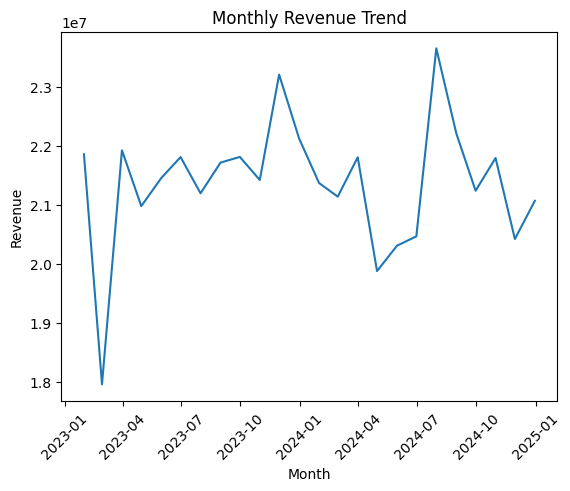

In [74]:
# 1 Create monthly revenue line chart.

plt.figure()

df['order_date'] = pd.to_datetime(df['order_date'])
df['revenue'] = df['quantity'] * df['unit_price']

monthly_revenue = df.set_index('order_date').resample('M')['revenue'].sum()

plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

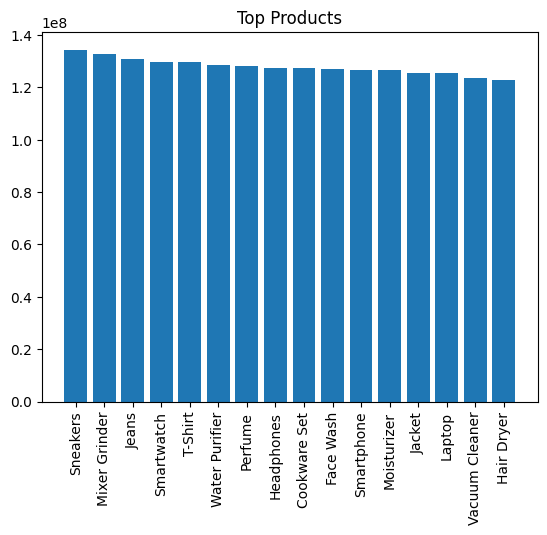

In [75]:
# 2 Create top products bar chart.

plt.figure()

top_products = df.groupby('product')['revenue'].sum().sort_values(ascending=False)
plt.bar(top_products.index, top_products.values)
plt.title("Top Products")
plt.xticks(rotation=90)
plt.show()

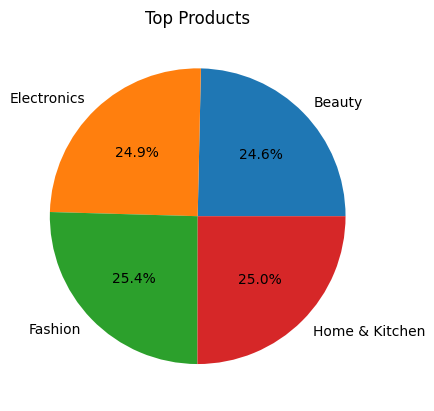

In [76]:
# 3 Create category revenue pie chart.

pie_chart = df.groupby('category')['revenue'].sum()
plt.pie(pie_chart.values, labels = pie_chart.index, autopct='%1.1f%%')
plt.title("Top Products")
plt.xticks(rotation=90)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

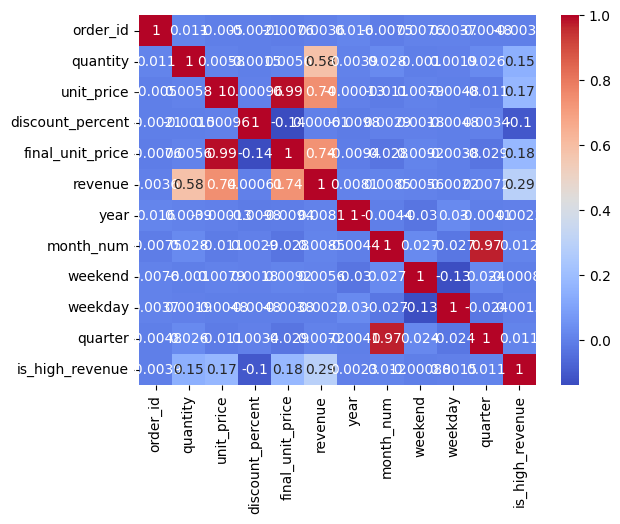

In [77]:
# 4 Create heatmap of correlations.

corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show

In [104]:
# 5 Build city vs category pivot visualization.

pivot = df.pivot_table(values = 'revenue', index = 'city', columns = 'category', aggfunc = 'sum')
pivot = pivot.fillna(0)
pivot = pivot.astype(float)

Text(0, 0.5, 'Total Revenue')

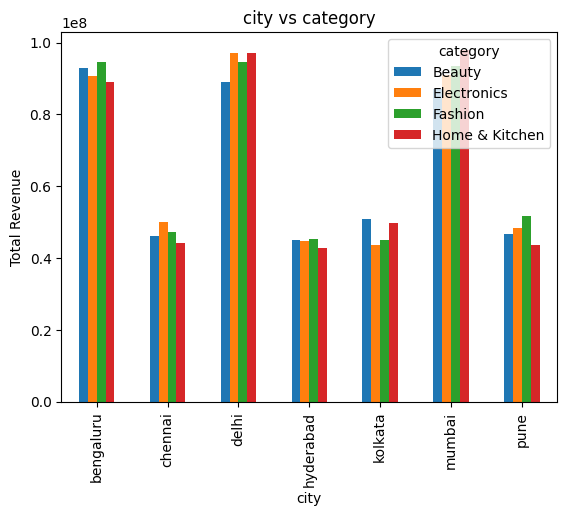

In [106]:
pivot.plot(kind = 'bar')

plt.title('city vs category')
plt.ylabel('Total Revenue')

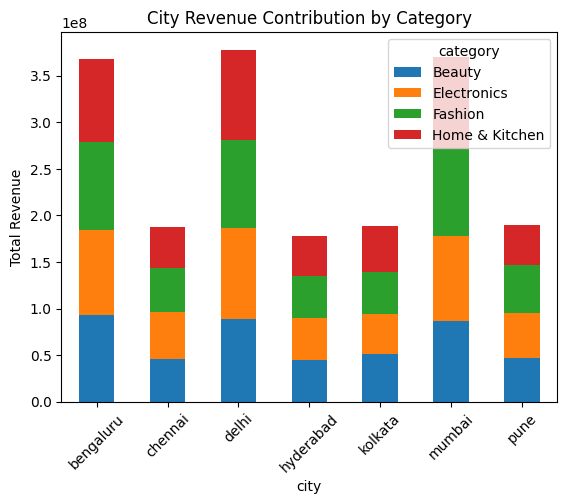

In [79]:
pivot.plot(kind='bar', stacked=True)

plt.title("City Revenue Contribution by Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

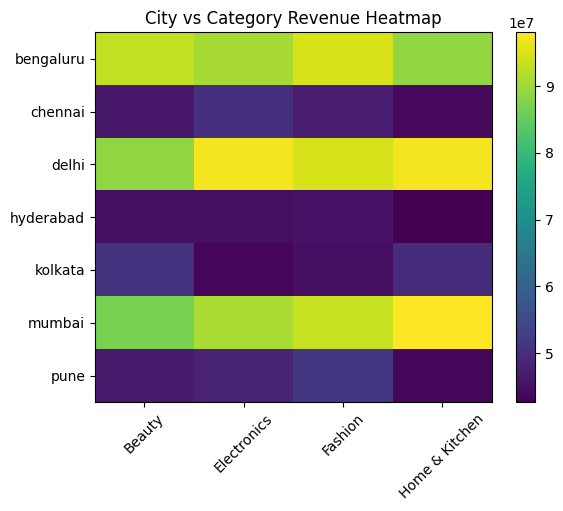

In [107]:
plt.figure()

plt.imshow(pivot, aspect='auto')
plt.colorbar()

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("City vs Category Revenue Heatmap")

plt.show()

## Business Insight Questions
